# Assignment 6: Experiment Tracking and Hyperparameter Optimization

---
_**Team 06**_

Name | Roll Number
---|---
Aditya Prakash Borate| 23110065
Swayam Giridhar Borate | 23110066

---

Github Repository : https://github.com/adi776borate/CS203-STT-Labs/tree/main/CS203_Lab_06

# Section 1: MLP Model Implementation & Experiment Tracking

In [ ]:
%%capture
!pip install wandb

In [ ]:
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.3 MB/s eta 0:00:00


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import wandb
import watermark

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Print versions using watermark
%reload_ext watermark
%watermark -v -m -p numpy,pandas,matplotlib,seaborn,tensorflow,sklearn,wandb

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 7.34.0

numpy     : 1.26.4
pandas    : 2.2.2
matplotlib: 3.10.0
seaborn   : 0.13.2
tensorflow: 2.18.0
sklearn   : 1.6.1
wandb     : 0.19.7

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.1.85+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



## 1. Implement a Multi-Layer Perceptron (MLP) Using the Iris Dataset

In [ ]:
# Load and preprocess Iris dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)  # Reshape for one-hot encoding
X.shape, y.shape

((150, 4), (150, 1))

In [ ]:
# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

In [ ]:
# Normalize features to [0,1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [ ]:
# Split dataset with stratification into train (70%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Further split into validation (10%) & test (20%) from remaining 30%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42)

In [ ]:
# Check the no. of sample of each class in train, val, and test

print("Training data:")
unique_train, counts_train = np.unique(np.argmax(y_train, axis=1), return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nValidation data:")
unique_val, counts_val = np.unique(np.argmax(y_val, axis=1), return_counts=True)
for label, count in zip(unique_val, counts_val):
    print(f"Class {label}: {count} samples")

print("\nTest data:")
unique_test, counts_test = np.unique(np.argmax(y_test, axis=1), return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")


Training data:
Class 0: 35 samples
Class 1: 35 samples
Class 2: 35 samples

Validation data:
Class 0: 5 samples
Class 1: 5 samples
Class 2: 5 samples

Test data:
Class 0: 10 samples
Class 1: 10 samples
Class 2: 10 samples


In [ ]:
# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)

## 2. Define and Train the MLP Model

In [ ]:
# Define Model
def make_model():
    inputs = keras.Input(shape=(4,), name="features") # Input layer: 4 neurons
    x = keras.layers.Dense(16, activation="relu", name="hidden_layer")(inputs) # Hidden layer: 16 neurons, ReLU activation
    outputs = keras.layers.Dense(3, activation="softmax", name="output_layer")(x) # Output layer: 3 neurons, softmax activation

    return keras.Model(inputs=inputs, outputs=outputs, name="MLP_Iris")

In [ ]:
# Training Step Function
def train_step(x, y, model, optimizer, loss_fn, train_acc_metric):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss_value = loss_fn(y, logits)

    grads = tape.gradient(loss_value, model.trainable_weights) # Calculate Gradients
    optimizer.apply_gradients(zip(grads, model.trainable_weights)) # Update the parameters

    train_acc_metric.update_state(y, logits) # Update the metric
    return loss_value

In [ ]:
# Validation Step Function
def val_step(x, y, model, loss_fn, val_acc_metric):
    val_logits = model(x, training=False) # Logits calculation using trained model
    loss_value = loss_fn(y, val_logits) # Loss calculation
    val_acc_metric.update_state(y, val_logits) # Update the metric
    return loss_value

In [ ]:
# Training Loop
def train(train_dataset, val_dataset, model, optimizer, train_acc_metric, val_acc_metric, epochs=10):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss = []
        val_loss = []

        # Training Loop
        for x_batch_train, y_batch_train in train_dataset:
            loss_value = train_step(x_batch_train, y_batch_train, model, optimizer, loss_fn, train_acc_metric)
            train_loss.append(float(loss_value))

        # Validation Loop
        for x_batch_val, y_batch_val in val_dataset:
            val_loss_value = val_step(x_batch_val, y_batch_val, model, loss_fn, val_acc_metric)
            val_loss.append(float(val_loss_value))

        # Compute Metrics
        train_acc = train_acc_metric.result()
        val_acc = val_acc_metric.result()

        # Store losses for plotting
        train_losses.append(np.mean(train_loss))
        val_losses.append(np.mean(val_loss))

        print(f"Train Loss: {train_losses[-1]:.4f} - Train Acc: {train_acc:.4f} - Val Loss: {val_losses[-1]:.4f} - Val Acc: {val_acc:.4f}")

        # Reset metrics
        train_acc_metric.reset_state()
        val_acc_metric.reset_state()

        # Log metrics with W&B
        wandb.log({"epoch": epoch+1,
                   "train_loss": train_losses[-1],
                   "train_acc": float(train_acc),
                   "val_loss": val_losses[-1],
                   "val_acc": float(val_acc)})

    return train_losses, val_losses

## 3. Evaluate Model Performance

In [ ]:
# Evaluate Model on Test Data
def evaluate(model, test_dataset):
    y_true = []
    y_pred = []

    # Predict over test data in batches
    for x_batch_test, y_batch_test in test_dataset:
        preds = model(x_batch_test, training=False)
        y_true.extend(np.argmax(y_batch_test.numpy(), axis=1))
        y_pred.extend(np.argmax(preds.numpy(), axis=1))

    # Compute Metrics using sklearn functions
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    conf_matrix = confusion_matrix(y_true, y_pred)

    print("\nTest Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}\n")


    # Log Metrics to W&B
    wandb.log({"test_accuracy": accuracy,
               "test_precision": precision,
               "test_recall": recall,
               "test_f1_score": f1})

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    wandb.log({"confusion_matrix": wandb.Image(plt.gcf())})  # Log to W&B
    plt.show()
    plt.close()

## Set Up Experiment Tracking with Weights & Biases


Epoch 1/50
Train Loss: 1.1481 - Train Acc: 0.4857 - Val Loss: 1.1549 - Val Acc: 0.4667

Epoch 2/50
Train Loss: 1.1361 - Train Acc: 0.5333 - Val Loss: 1.1432 - Val Acc: 0.4667

Epoch 3/50
Train Loss: 1.1249 - Train Acc: 0.5143 - Val Loss: 1.1319 - Val Acc: 0.4000

Epoch 4/50
Train Loss: 1.1143 - Train Acc: 0.4857 - Val Loss: 1.1209 - Val Acc: 0.4000

Epoch 5/50
Train Loss: 1.1044 - Train Acc: 0.4667 - Val Loss: 1.1110 - Val Acc: 0.4000

Epoch 6/50
Train Loss: 1.0954 - Train Acc: 0.4381 - Val Loss: 1.1021 - Val Acc: 0.4000

Epoch 7/50
Train Loss: 1.0871 - Train Acc: 0.4190 - Val Loss: 1.0938 - Val Acc: 0.4000

Epoch 8/50
Train Loss: 1.0793 - Train Acc: 0.4095 - Val Loss: 1.0859 - Val Acc: 0.4000

Epoch 9/50
Train Loss: 1.0718 - Train Acc: 0.4000 - Val Loss: 1.0786 - Val Acc: 0.4000

Epoch 10/50
Train Loss: 1.0646 - Train Acc: 0.4095 - Val Loss: 1.0716 - Val Acc: 0.4000

Epoch 11/50
Train Loss: 1.0576 - Train Acc: 0.4095 - Val Loss: 1.0648 - Val Acc: 0.4000

Epoch 12/50
Train Loss: 1.050

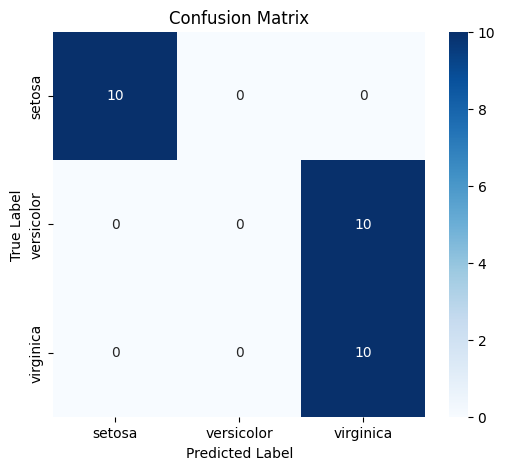

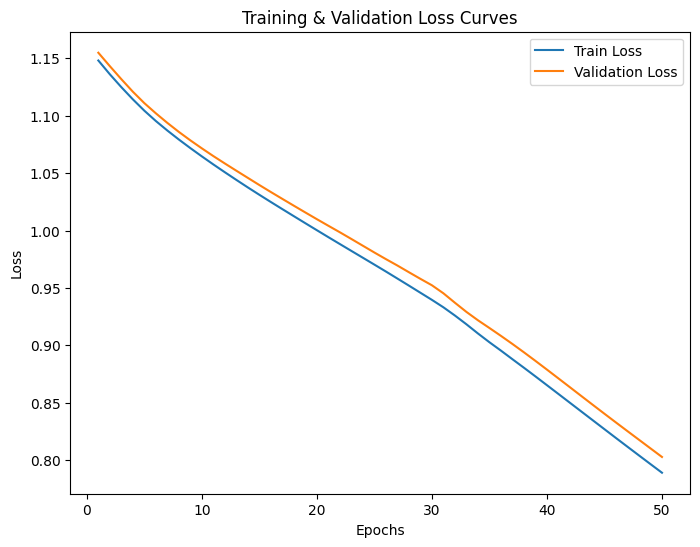

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
train_acc,▃▅▄▃▃▁▁▁▁▁▂▃▄▅▅▆▆▇██████████████████████
train_loss,███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
val_acc,▃▃▁▁▁▁▁▁▁▁▁▁▁▃▃▅▅▆▆▆▆▆▆▆▆▆▆▆████████████
val_loss,███▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
epoch,50
test_accuracy,0.66667


In [ ]:
# Initialize Weights & Biases (W&B)
config = {
    "learning_rate": 0.001,
    "epochs": 50,
    "batch_size": 32,
    "architecture": "MLP",
    "dataset": "Iris",
    "layers": ["Dense(16, ReLU)", "Dense(3, Softmax)"]
}

run = wandb.init(project="MLP-IRIS", config=config, name="run1")
config = wandb.config

# Create model, optimizer, and loss function
model = make_model()

# Define optimizer, loss, and metrics
optimizer = keras.optimizers.Adam(learning_rate=config.learning_rate)
loss_fn = keras.losses.CategoricalCrossentropy()
train_acc_metric = keras.metrics.CategoricalAccuracy()
val_acc_metric = keras.metrics.CategoricalAccuracy()

# Start Training
train_losses, val_losses = train(train_dataset, val_dataset, model, optimizer, train_acc_metric, val_acc_metric, epochs=config.epochs)

# Evaluate Model
print("==="*30)
evaluate(model, test_dataset)

# Plot Loss Curves
plt.figure(figsize=(8, 6))
plt.plot(range(1, config.epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, config.epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curves")
plt.legend()
wandb.log({"loss_curve": wandb.Image(plt.gcf())}) # Log to W&B first
plt.show()
plt.close()

# Finish W&B Run
wandb.finish()